# Assignment 03: KMeans Clustering

This notebook implements KMeans clustering for three data types:

1. tabular data using the first three numerical dimensions,
2. MNIST image vectors, and
3. Bangla news text represented with manually computed TF-IDF features.


In [1]:
# Download / locate the diabetes dataset used in Part 3A.
# In Kaggle notebooks, the dataset may already be mounted under /kaggle/input.

from pathlib import Path

DATASET_DIR = Path('/kaggle/input/diabetes-data-set')

try:
    import kagglehub
    downloaded_path = Path(kagglehub.dataset_download('mathchi/diabetes-data-set'))
    if downloaded_path.exists():
        DATASET_DIR = downloaded_path
except Exception as exc:
    print('kagglehub download skipped; using local Kaggle path if available.')
    print('Reason:', exc)

print('Diabetes dataset directory:', DATASET_DIR)


Using Colab cache for faster access to the 'diabetes-data-set' dataset.
Path to dataset files: /kaggle/input/diabetes-data-set


## Custom KMeans Implementation

In [2]:
import os
import random
import math
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go


In [3]:
# Initialize K centroids by randomly selecting K distinct data points.

def initialize_centroids_simple(data, dimension, k):
    """
    Initialize K centroids by randomly selecting K data points.

    Parameters
    ----------
    data : np.ndarray of shape (N, D)
        Full data matrix.
    dimension : int
        Number of dimensions to use (first 'dimension' columns).
    k : int
        Number of clusters.

    Returns
    -------
    centroids : np.ndarray of shape (k, dimension)
    """
    N = data.shape[0]
    # randomly choose K distinct indices
    chosen_indices = np.random.choice(N, size=k, replace=False)
    # take those rows as centroids (only first 'dimension' features)
    centroids = data[chosen_indices, :dimension].astype(float).copy()
    return centroids


In [4]:
# ---------- Distance function ----------
# This is used in 5(a) inside kmeans.

def get_euclidean_distance(p1, p2):

    return math.sqrt(np.sum((p1 - p2) ** 2))


In [5]:
# ---------- Objective function J ----------
# Assignment 3A – Step 5(d):
# "We evaluate the quality of the clustering using the clustering objective value:
#  J = sum over i of ||x_i - z_{cluster(i)}||^2
#  Terminate when |J − J_prev| ≤ 10^−5 J_prev."

def calculate_objective(data, centroids, cluster_affiliation):
    """
    Compute clustering objective J = sum_i || x_i - centroid_{c_i} ||^2
    """
    J = 0.0
    for i, point in enumerate(data):
        c = cluster_affiliation[i]
        centroid = centroids[c]
        diff = point - centroid
        J += np.sum(diff ** 2)
    return J


In [6]:
# ---------- KMeans main function ----------


def kmeans(data, dimension, k, max_iterations=300, tol=1e-5, verbose=True):
    """
    K-means clustering algorithm.

    Parameters
    ----------
    data : np.ndarray of shape (N, D)
        Input data (we will use only first 'dimension' features).
    dimension : int
        Number of features to use.
    k : int
        Number of clusters.
    max_iterations : int
        Safety cap on number of iterations.
    tol : float
        Termination threshold for |J - J_prev| <= tol * J_prev.
    verbose : bool
        Print objective value per iteration if True.

    Returns
    -------
    centroids : np.ndarray of shape (k, dimension)
    cluster_affiliation : np.ndarray of shape (N,)
    """
    # Only use the first 'dimension' columns (Assignment 3A – Step 1 & 3)
    data = data[:, :dimension]
    N = data.shape[0]

    # Assignment 3A – Step 4: initialize centroids
    centroids = initialize_centroids_simple(data, dimension, k)

    # cluster_affiliation: [cluster_number, ..., ...]
    # initialize with -1 as in the skeleton
    cluster_affiliation = np.array([-1 for _ in range(N)], dtype=int)

    flag = True
    iteration = 0
    J_prev = None  # for termination criterion

    while flag and iteration < max_iterations:
        # -----------------------------------
        # 5(a) Assignment step:
        #    calculate cluster_affiliation array based on distances
        # -----------------------------------
        for i, point in enumerate(data):
            min_distance = float('inf')
            min_distance_index = None

            # find closest centroid for this point
            for cluster_index, centroid in enumerate(centroids):
                distance = get_euclidean_distance(centroid, point)
                if distance < min_distance:
                    min_distance = distance
                    min_distance_index = cluster_index

            # update cluster for each data point
            cluster_affiliation[i] = min_distance_index

        # -----------------------------------
        # 5(b) & 5(c) Recompute centroids
        #    - count number of points per cluster in cluster_point_count
        #    - recompute centroid of each cluster as mean of its points
        # -----------------------------------
        new_centroids = np.zeros((k, dimension), dtype=float)
        cluster_point_count = np.zeros(k, dtype=int)

        # count and sum
        for i, point in enumerate(data):
            c = cluster_affiliation[i]
            cluster_point_count[c] += 1
            new_centroids[c] += point

        # mean (or reinitialize empty clusters)
        for c in range(k):
            if cluster_point_count[c] > 0:
                new_centroids[c] /= cluster_point_count[c]
            else:
                # empty cluster: reinitialize randomly from data
                rand_idx = np.random.randint(0, N)
                new_centroids[c] = data[rand_idx]

        centroids = new_centroids

        # -----------------------------------
        # 5(d) Termination criterion based on J
        # -----------------------------------
        J = calculate_objective(data, centroids, cluster_affiliation)

        if verbose:
            print(f"Iteration {iteration+1}: J = {J:.6f}")

        if J_prev is not None:
            # |J − J_prev| ≤ 10−5 J_prev  (tol = 10^-5 by default)
            if abs(J - J_prev) <= tol * J_prev:
                if verbose:
                    print("Converged based on objective function change.")
                flag = False

        J_prev = J
        iteration += 1

    if iteration >= max_iterations and verbose:
        print("Reached maximum number of iterations without strict convergence.")

    return centroids, cluster_affiliation

## Part 3A: KMeans on the Diabetes Dataset

### 3A workflow

This section loads the diabetes dataset, keeps the first three numerical features, sets `K` from the number of ground-truth classes, runs the custom KMeans implementation, and visualizes the result in 3D using Plotly. Point shape represents the original class label and marker color represents the assigned cluster.

In [7]:
def load_and_preprocess_diabetes(filepath):
    """
    Loads and preprocesses the diabetes dataset.
    This step is BEFORE Assignment 3A requirements and ensures clean data.

    Preprocessing done:
    1. Load CSV
    2. Check for NaN / null / empty cells
    3. Replace or drop invalid values
    4. Check for negative values (invalid for this dataset)
    5. Separate features and labels (Outcome)
    """

    print("Loading dataset...")
    df = pd.read_csv(filepath)

    # ---------------------------
    # 1. Check for NaN / null
    # ---------------------------
    print("\nChecking for NaN values...")
    print(df.isnull().sum())

    # If NaN exist → fill with mean (or remove)
    if df.isnull().values.any():
        print("NaN detected → filling with column mean")
        df.fillna(df.mean(), inplace=True)

    # ---------------------------
    # 2. Check for negative values
    # ---------------------------
    print("\nChecking for negative values (should not exist):")
    neg_mask = (df.iloc[:, :-1] < 0).any(axis=1)
    print("Negative rows found:", neg_mask.sum())

    if neg_mask.sum() > 0:
        print("Fixing negative values → replacing with column median")
        df[df < 0] = df.median()

    # ---------------------------
    # 3. Check for empty strings (rare in numeric datasets)
    # ---------------------------
    print("\nChecking for empty string values:")
    empty_mask = df.astype(str).eq("").any(axis=1)
    print("Empty rows found:", empty_mask.sum())

    if empty_mask.sum() > 0:
        print("Removing empty rows.")
        df = df[~empty_mask]

    # ---------------------------
    # 4. Separate features vs class labels
    # Assignment 3A Step 1 & 3
    # ---------------------------
    data = df.iloc[:, :-1].values       # all feature columns
    classlabel = df.iloc[:, -1].values  # Outcome column

    print("\nDataset preprocessed successfully.")
    print("Final shape:", data.shape)

    return data, classlabel


In [8]:
# ============================
# 3A: Visualization + Misclassification
# ============================

def visualize_clusters_3d(data, cluster_affiliation, centroids, classlabel):
    """
    Assignment 3A – Step 6
    Draws a 3D scatter plot where:

    (i)  Shape = ground truth class label
    (ii) Color = cluster affiliation
    """

    # Use only first 3 dimensions (assignment requirement)
    data_3d = data[:, :3]

    # Unique classes (ground truth shapes)
    unique_classes = np.unique(classlabel)

    # Ground-truth shapes
    shape_candidates = ['circle', 'square', 'triangle-up']
    shape_map = {}
    for idx, cls in enumerate(unique_classes):
        shape_map[cls] = shape_candidates[idx % len(shape_candidates)]

    # Universal cluster colors for up to 20 clusters
    color_list = [
        'blue', 'red', 'yellow', 'green', 'purple',
        'orange', 'pink', 'brown', 'cyan', 'magenta'
    ]
    cluster_color_map = {i: color_list[i % len(color_list)] for i in range(20)}

    fig = go.Figure()

    # One trace per TRUE CLASS (correct shape grouping)
    for cls in unique_classes:
        idx = np.where(classlabel == cls)[0]

        x = data_3d[idx, 0]
        y = data_3d[idx, 1]
        z = data_3d[idx, 2]

        # Colors for these points based on cluster affiliation
        colors = [
            cluster_color_map.get(int(cluster_affiliation[i]), 'gray')
            for i in idx
        ]

        fig.add_trace(go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode='markers',
            name=f'Class {cls}',
            marker=dict(
                size=5,
                symbol=shape_map[cls],     # shape from class
                color=colors,              # color from cluster
                line=dict(width=0.5, color='black')
            )
        ))

    # Plot centroids
    fig.add_trace(go.Scatter3d(
        x=centroids[:, 0],
        y=centroids[:, 1],
        z=centroids[:, 2],
        mode='markers',
        name='Centroids',
        marker=dict(
            size=12,
            symbol='x',
            color='black',
            line=dict(width=2, color='white')
        )
    ))

    fig.update_layout(
        title='KMeans on Diabetes Data (First 3 Features)',
        scene=dict(
            xaxis_title='Feature 1',
            yaxis_title='Feature 2',
            zaxis_title='Feature 3'
        ),
        showlegend=True
    )

    fig.show()



def count_misclassifications(cluster_affiliation, classlabel, k):
    """
    Assignment 3A – Step 6(iii)
    Count misclustered points based on dominant class in each cluster.
    (Same shape but different color)
    """

    misclassified = 0

    for cluster in range(k):
        mask = (cluster_affiliation == cluster)
        labels_in_cluster = classlabel[mask]

        if labels_in_cluster.size == 0:
            print(f"Cluster {cluster}: empty")
            continue

        unique, counts = np.unique(labels_in_cluster, return_counts=True)
        dominant_class = unique[np.argmax(counts)]
        dominant_count = counts.max()
        total_in_cluster = len(labels_in_cluster)

        mis_here = total_in_cluster - dominant_count
        misclassified += mis_here

        print(
            f"Cluster {cluster}: total={total_in_cluster}, "
            f"dominant class={dominant_class} ({dominant_count}), "
            f"misclustered={mis_here}"
        )

    return misclassified


In [13]:
def main_3A():
    """
    Driver for Assignment 3A.
    - Loads & preprocesses diabetes data
    - Uses first 3 dimensions
    - Runs KMeans with K = number of classes
    - Visualizes 3D plot
    - Counts misclustered points
    """
    np.random.seed(42)
    start = time.time()

    # Locate diabetes.csv from the Kaggle-mounted folder or kagglehub download.
    filepath = Path(DATASET_DIR) / 'diabetes.csv'
    if not filepath.exists():
        filepath = Path('/kaggle/input/diabetes-data-set/diabetes.csv')
    print('Loading data from:', filepath)

    # Load + preprocess (NaN, negatives, empties)  [Assignment 3A – Step 1 & 3]
    data, classlabel = load_and_preprocess_diabetes(str(filepath))

    # Use first 3 dimensions only  [Step 1]
    data_3d = data[:, :3]
    dimension = 3

    # K = number of unique classes in Outcome  [Step 3]
    K = len(np.unique(np.array(classlabel)))
    print("Data shape (N, D):", data_3d.shape)
    print("Number of clusters K:", K)

    # Run KMeans  [Step 4 & 5]
    centroids, cluster_affiliation = kmeans(
        data=data_3d,
        dimension=dimension,
        k=K,
        max_iterations=300,
        tol=1e-5,
        verbose=True
    )

    print("\nFinal centroids:")
    for idx, c in enumerate(centroids):
        print(f"Centroid {idx}: {c}")

    # 3D visualization  [Step 6 (i),(ii)]
    print("\nGenerating 3D visualization...")
    visualize_clusters_3d(data_3d, cluster_affiliation, centroids, classlabel)

    # Misclassification count  [Step 6 (iii)]
    print("\nCounting misclustered points...")
    total_mis = count_misclassifications(cluster_affiliation, classlabel, K)
    N = data_3d.shape[0]
    acc = (N - total_mis) / N * 100.0

    print(f"\nTotal misclustered points: {total_mis} / {N}")
    print(f"Approx. clustering accuracy (majority-class rule): {acc:.2f}%")
    print(f"\nDuration: {time.time() - start:.2f} seconds")


In [14]:
main_3A()

Loading data from: /kaggle/input/diabetes-data-set/diabetes.csv
Loading dataset...

Checking for NaN values...
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Checking for negative values (should not exist):
Negative rows found: 0

Checking for empty string values:
Empty rows found: 0

Dataset preprocessed successfully.
Final shape: (768, 8)
Data shape (N, D): (768, 3)
Number of clusters K: 2
Iteration 1: J = 718769.321801
Iteration 2: J = 624473.277933
Iteration 3: J = 585097.815390
Iteration 4: J = 576102.653702
Iteration 5: J = 571033.211794
Iteration 6: J = 568640.620555
Iteration 7: J = 568177.022917
Iteration 8: J = 568124.446493
Iteration 9: J = 568111.882925
Iteration 10: J = 568101.228000
Iteration 11: J = 568101.228000
Converged based on object


Counting misclustered points...
Cluster 0: total=484, dominant class=0 (384), misclustered=100
Cluster 1: total=284, dominant class=1 (168), misclustered=116

Total misclustered points: 216 / 768
Approx. clustering accuracy (majority-class rule): 71.88%

Duration: 0.25 seconds


## Part 3B: KMeans Clustering on MNIST Images

In [15]:
# ============================
# 3B: Extra imports (MNIST, TSNE, metrics, plots)
# ============================

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import davies_bouldin_score, rand_score
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots
from tensorflow.keras.datasets import mnist


### Load and vectorize MNIST images

In [16]:
# ============================
# 3B: Load MNIST data
# ============================

def load_mnist_data():
    """
    Assignment 3B – Steps 2,3,4

    Loads MNIST train data using TensorFlow (built-in in Colab).

    Returns:
      digits_row_major : (60000, 784)  # each row = flattened 28x28 image
      digits_col_major : (784, 60000)  # as assignment says: 784 x 60000
      labels           : (60000,)      # digit labels 0–9

    Notes (matching assignment text):
    - We only use labels later for external validation (purity, Rand index).
    - Each column (in digits_col_major) is a 784-length vector in [0,1].
    """

    print("Loading MNIST using TensorFlow...")
    (x_train, y_train), _ = mnist.load_data()   # x_train: (60000, 28, 28)

    # Normalize pixels to [0,1]
    x_train = x_train.astype(np.float32) / 255.0

    # Flatten each image into a 784-dim vector
    digits_row_major = x_train.reshape(60000, 28 * 28)  # (60000, 784)

    # Transpose to get 784 x 60000, as mentioned in assignment
    digits_col_major = digits_row_major.T               # (784, 60000)

    labels = y_train.astype(int)                        # (60000,)

    print("digits_row_major shape (N, 784):", digits_row_major.shape)
    print("digits_col_major shape (784, N):", digits_col_major.shape)
    print("labels shape:", labels.shape)

    return digits_row_major, digits_col_major, labels


### Run KMeans on MNIST with K = 10

In [17]:
# ============================
# 3B: KMeans on MNIST with k=10
# ============================

def run_kmeans_mnist():
    """
    Assignment 3B – Step 5:
    Apply the K-means algorithm to N = 60000 vectors, with k = 10 groups,
    starting from a random initial group assignment.

    Reuses the same kmeans() implementation from 3A.
    """

    # Load MNIST
    digits_row_major, digits_col_major, labels = load_mnist_data()

    # Use row-major for KMeans: shape (N, 784)
    data = digits_row_major
    N, D = data.shape
    k = 10          # 10 digit groups (0–9), as required
    dimension = D   # 784

    print("\nRunning KMeans on MNIST...")
    print("N =", N, ", dimension =", dimension, ", k =", k)

    centroids, cluster_affiliation = kmeans(
        data=data,
        dimension=dimension,
        k=k,
        max_iterations=100,      # you can increase if needed
        tol=1e-5,
        verbose=True
    )

    print("\nKMeans finished.")
    print("Centroids shape:", centroids.shape)               # (10, 784)
    print("Cluster affiliations shape:", cluster_affiliation.shape)  # (60000,)

    return data, labels, centroids, cluster_affiliation


### Visual validation: MNIST centroid images

In [19]:
# ============================
# 3B Visual 1: Show centroid images
# ============================

def show_centroid_images(centroids, num_rows=2, num_cols=5):
    """
    Assignment 3B – Step 6:
    Take the 10 centroid vectors (784,) and reshape them into 28x28 images.
    Display them as grayscale images. Visually, they should look like digits.
    """
    k, dim = centroids.shape
    assert dim == 784, "Centroids must be 784-dimensional for MNIST."

    plt.figure(figsize=(12, 5))
    for i in range(k):
        img = centroids[i].reshape(28, 28)

        plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Centroid {i}")
        plt.axis('off')

    plt.suptitle("MNIST KMeans – Centroid Images")
    plt.tight_layout()
    plt.show()


### Visual validation: 3D t-SNE plot for 1,000 MNIST samples

In [23]:
import plotly.graph_objects as go

def visualize_mnist_tsne_3d_interactive(data, cluster_affiliation, centroids, sample_size=1000, random_state=42):
    """
    Interactive 3D t-SNE plot for MNIST using Plotly.
    Fully zoomable, rotatable, and hoverable.
    """
    np.random.seed(random_state)

    N = data.shape[0]
    sample_size = min(sample_size, N)

    # Random sample of 1000 points
    idx = np.random.choice(N, size=sample_size, replace=False)
    data_sample = data[idx]
    clusters_sample = cluster_affiliation[idx]

    # Combine sample + centroids for joint embedding
    combined = np.vstack([data_sample, centroids])  # (1000 + 10, 784)

    print("Running t-SNE (this may take ~30 seconds)...")
    tsne = TSNE(n_components=3, random_state=random_state, perplexity=30, init='random')
    combined_tsne = tsne.fit_transform(combined)

    data_tsne = combined_tsne[:sample_size]
    centroids_tsne = combined_tsne[sample_size:]


    fig = go.Figure()

    # Colors for clusters
    color_list = [
        'blue', 'red', 'yellow', 'green', 'purple',
        'orange', 'pink', 'brown', 'cyan', 'magenta'
    ]
    cluster_color_map = {i: color_list[i % len(color_list)] for i in range(20)}

    # Plot sample points
    for c in np.unique(clusters_sample):
        mask = (clusters_sample == c)
        fig.add_trace(go.Scatter3d(
            x=data_tsne[mask, 0],
            y=data_tsne[mask, 1],
            z=data_tsne[mask, 2],
            mode='markers',
            marker=dict(
                size=3,
                color=cluster_color_map[int(c)],
                opacity=0.7
            ),
            name=f'Cluster {c}'
        ))

    # Plot centroids as large X symbols
    fig.add_trace(go.Scatter3d(
        x=centroids_tsne[:, 0],
        y=centroids_tsne[:, 1],
        z=centroids_tsne[:, 2],
        mode='markers',
        marker=dict(
            size=15,
            symbol='x',
            color='black'
        ),
        name='Centroids'
    ))

    fig.update_layout(
        title='Interactive 3D t-SNE Visualization of MNIST Clusters',
        scene=dict(
            xaxis_title="TSNE-1",
            yaxis_title="TSNE-2",
            zaxis_title="TSNE-3",
        ),
        width=900,
        height=700
    )

    fig.show()


### Quantitative validation metrics

#### Internal validation: Davies-Bouldin index and Dunn index

In [25]:
# ============================
# 3B Metrics: Internal Validation
# ============================

def compute_davies_bouldin_index(data, cluster_affiliation):
    """
    Assignment 3B – Step 8(a)(i)
    Davies–Bouldin index using sklearn (lower is better).
    """
    return davies_bouldin_score(data, cluster_affiliation)


def compute_dunn_index_approx(data, cluster_affiliation, centroids):
    """
    Assignment 3B – Step 8(a)(ii)
    Approximate Dunn index:
      inter = min distance between any two centroids
      intra = max cluster radius (max distance from points to their centroid)
    Dunn ≈ inter / intra
    """
    k = centroids.shape[0]

    # Inter-cluster distance: min centroid-centroid distance
    inter = np.inf
    for i in range(k):
        for j in range(i + 1, k):
            d = np.linalg.norm(centroids[i] - centroids[j])
            if d < inter:
                inter = d

    # Intra-cluster distance: max radius across clusters
    intra = 0.0
    for c in range(k):
        mask = (cluster_affiliation == c)
        if not np.any(mask):
            continue
        points = data[mask]
        dists = np.linalg.norm(points - centroids[c], axis=1)
        radius = dists.max()
        intra = max(intra, radius)

    if intra == 0:
        return np.inf

    return inter / intra


#### External validation: Purity and Rand index

In [26]:
# ============================
# 3B Metrics: External Validation
# ============================

def compute_purity(true_labels, cluster_affiliation):
    """
    Assignment 3B – Step 8(b)(i)
    Purity = (1/N) * sum_over_clusters max_class_count_in_cluster.
    """
    N = len(true_labels)
    clusters = np.unique(cluster_affiliation)

    correct = 0
    for c in clusters:
        mask = (cluster_affiliation == c)
        labels_c = true_labels[mask]
        if len(labels_c) == 0:
            continue
        values, counts = np.unique(labels_c, return_counts=True)
        correct += counts.max()

    return correct / N


def compute_rand_index(true_labels, cluster_affiliation):
    """
    Assignment 3B – Step 8(b)(ii)
    Rand Index using sklearn.metrics.rand_score (0–1, higher is better).
    """
    return rand_score(true_labels, cluster_affiliation)


### 3B driver

Loading MNIST using TensorFlow...
digits_row_major shape (N, 784): (60000, 784)
digits_col_major shape (784, N): (784, 60000)
labels shape: (60000,)

Running KMeans on MNIST...
N = 60000 , dimension = 784 , k = 10
Iteration 1: J = 2631293.358823
Iteration 2: J = 2500060.614526
Iteration 3: J = 2463748.295821
Iteration 4: J = 2425426.869526
Iteration 5: J = 2389619.313994
Iteration 6: J = 2371609.158004
Iteration 7: J = 2362360.117094
Iteration 8: J = 2357258.457151
Iteration 9: J = 2354837.770411
Iteration 10: J = 2353903.060640
Iteration 11: J = 2353463.296047
Iteration 12: J = 2353209.698602
Iteration 13: J = 2353056.306560
Iteration 14: J = 2352967.739027
Iteration 15: J = 2352913.831661
Iteration 16: J = 2352885.579215
Iteration 17: J = 2352864.071670
Converged based on objective function change.

KMeans finished.
Centroids shape: (10, 784)
Cluster affiliations shape: (60000,)


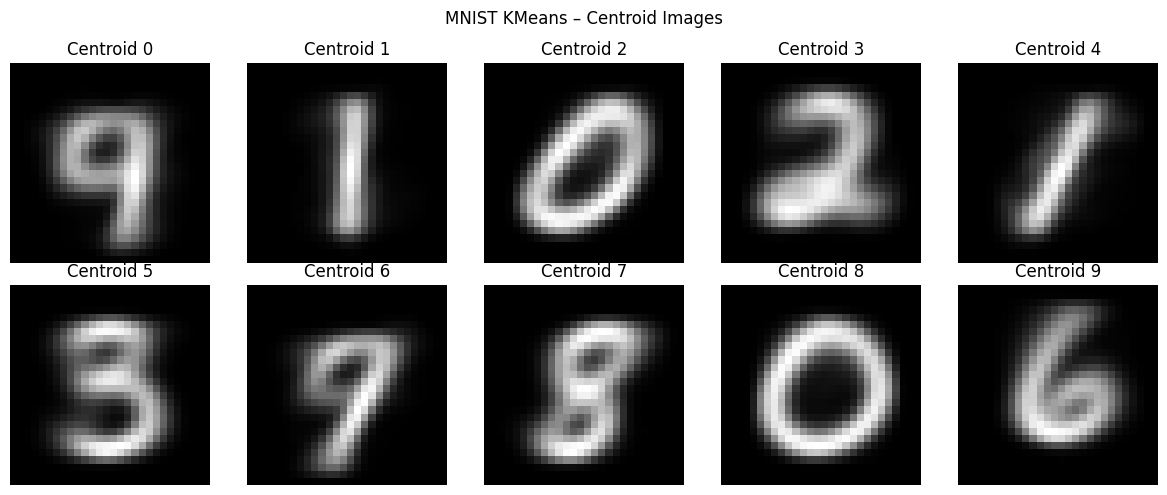

Running t-SNE (this may take ~30 seconds)...



Computing analytical / quantitative validation metrics...
Davies–Bouldin Index (lower is better): 2.8399
Dunn Index (higher is better, approx.): 0.344381
Purity (0–1, higher better): 0.5911
Rand Index (0–1, higher better): 0.8797


In [28]:
# ============================
# 3B: Main Driver
# ============================

def main_3B():
    """
    Driver for Assignment 3B:
    - Load MNIST
    - Run KMeans with k = 10
    - Visual validation: centroid images + t-SNE 3D
    - Analytical validation: DBI, Dunn, Purity, Rand Index
    """
    # 1. KMeans on MNIST
    data, labels, centroids, clusters = run_kmeans_mnist()

    # 2. Visual validation – centroid images
    show_centroid_images(centroids)

    # 3. Visual validation – t-SNE 3D on 1000 points
    visualize_mnist_tsne_3d_interactive(data, clusters, centroids, sample_size=1000)

    # 4. Analytical / quantitative validation
    print("\nComputing analytical / quantitative validation metrics...")

    dbi = compute_davies_bouldin_index(data, clusters)
    dunn = compute_dunn_index_approx(data, clusters, centroids)
    purity = compute_purity(labels, clusters)
    ri = compute_rand_index(labels, clusters)

    print(f"Davies–Bouldin Index (lower is better): {dbi:.4f}")
    print(f"Dunn Index (higher is better, approx.): {dunn:.6f}")
    print(f"Purity (0–1, higher better): {purity:.4f}")
    print(f"Rand Index (0–1, higher better): {ri:.4f}")


# Run 3B
main_3B()


## Part 3C: KMeans Text Clustering on Prothom Alo News

In [38]:
# 3C: extra imports for text clustering
import os
import re
import numpy as np
import pandas as pd

from collections import Counter

from sklearn.manifold import TSNE
from sklearn.metrics import davies_bouldin_score, rand_score
from sklearn.metrics import pairwise_distances
import plotly.graph_objects as go


In [47]:
# 3C.1 and 3C.2: load dataset and select 200 documents from each of 6 categories.

def load_prothom_alo_1200(path_tsv):
    """
    Load Prothom Alo news data and return 1,200 documents:
    200 documents from each of six categories.
    """
    df = pd.read_csv(
        path_tsv,
        sep='\t',
        header=0,
        names=['text', 'label'],
        quoting=3,
        on_bad_lines='skip',
        engine='python'
    )

    print('Total rows in train.tsv after cleaning:', df.shape)
    print('Label distribution:\n', df['label'].value_counts())

    selected_labels = df['label'].value_counts().head(6).index.tolist()
    groups = []
    for label in selected_labels:
        groups.append(df[df['label'] == label].head(200))

    df_1200 = pd.concat(groups).reset_index(drop=True)

    print('\nSelected subset shape:', df_1200.shape)
    print('Subset label distribution:\n', df_1200['label'].value_counts())

    return df_1200

PROTHOM_ALO_PATH = '/content/prothom_alo_dataset/train.tsv'
df_1200 = load_prothom_alo_1200(PROTHOM_ALO_PATH)


Total rows in train.tsv after cleaning: (11108, 2)
Label distribution:
 label
kolkata          4596
state            2182
national         1404
sports           1255
entertainment    1157
international     514
Name: count, dtype: int64

Selected subset shape: (1200, 2)
Subset label distribution:
 label
entertainment    200
state            200
sports           200
national         200
kolkata          200
international    200
Name: count, dtype: int64


### Text preprocessing: tokenization, normalization, stopword removal, and stemming

In [49]:
# 3C.3 (a–d): tokenize, normalize, remove stopwords, stem


bangla_stopwords = set("""
এবং কিন্তু অথবা যেখানে যখন থেকে পর্যন্ত জন্য যারা যা এই সেই আমি তুমি তবে আরো সাথে মধ্যে উপর নিচে হলে হবে ছিল ছিলাম যেন যেমন তেমন ছিলো হবো ওরা তারা এগুলো ওগুলো এটি তা সেইটা
""".split())

def simple_stem(word):
    """
    Simple suffix stripper for basic Bangla text normalization.
    """
    suffixes = ["গুলো", "গুলি", "রা", "দের", "কে", "তে", "তো", "ছি", "ছিল", "তা", "টা", "তোম", "তোমার"]
    for suf in suffixes:
        if word.endswith(suf) and len(word) > len(suf) + 1:
            return word[:-len(suf)]
    return word

def preprocess_text(text):
    """
    - lowercase
    - keep Bangla letters, English letters, digits and spaces
    - split by whitespace
    - remove stopwords
    - apply simple stemming
    """
    text = str(text).lower()
    text = re.sub(r"[^০-৯a-zA-Zঅ-হ্ ]", " ", text)
    tokens = text.split()

    clean_tokens = []
    for t in tokens:
        if t in bangla_stopwords:
            continue
        stemmed = simple_stem(t)
        if len(stemmed) > 1:
            clean_tokens.append(stemmed)

    return clean_tokens

# apply to all 1200 docs
tokenized_docs = [preprocess_text(txt) for txt in df_1200["text"].tolist()]
true_labels_3c = df_1200["label"].values  # ground truth for external validation

print("Example tokens for doc 0:\n", tokenized_docs[0][:30])


Example tokens for doc 0:
 ['প্রজ', 'পত', 'প্রজ', 'পত', 'আম', 'ইচ্ছ', 'বন', 'বন', 'ওড', 'আর', 'শব', 'গন্ধ', 'সব', 'কণ্ঠ', 'অপ', 'র্ব', 'সব', 'নগ', 'চ্ছ', 'উপহ', 'সব', 'প্রজন্ম', 'নপ্র', 'গ্য', 'কর্কটর', 'আক্র', 'ন্ত', 'সব', 'গত', 'বছর']


### Vocabulary construction with Zipf-style filtering

In [50]:
# 3C.3 (e, f): Zipf filtering + vocabulary

# count all tokens
freq_counter = Counter()
for toks in tokenized_docs:
    freq_counter.update(toks)

# sort by frequency (most common first)
sorted_words = freq_counter.most_common()
total_terms = len(sorted_words)

print("Total unique terms before Zipf filtering:", total_terms)

# discard top 1% and bottom 1% by frequency (you can tweak these percentages)
top_cut = int(total_terms * 0.01)
bottom_cut = int(total_terms * 0.01)

# keep mid-frequency terms
zipf_filtered = sorted_words[top_cut: total_terms - bottom_cut]

vocab = sorted([w for (w, c) in zipf_filtered])
V = len(vocab)
print("Vocabulary size after Zipf filtering:", V)

# word → index map
word_index = {w: i for i, w in enumerate(vocab)}


Total unique terms before Zipf filtering: 8239
Vocabulary size after Zipf filtering: 8075


### Manual TF, normalized TF, IDF, and TF-IDF matrices

In [51]:
# 3C.3 (g): TF matrix (manual)

N = len(tokenized_docs)
D = V

TF = np.zeros((N, D), dtype=np.float32)

for doc_idx, tokens in enumerate(tokenized_docs):
    for t in tokens:
        j = word_index.get(t, None)
        if j is not None:
            TF[doc_idx, j] += 1.0

print("TF shape:", TF.shape)

# 3C.3 (h): normalized TF matrix (manual)
TF_norm = np.zeros_like(TF)

for i in range(N):
    max_tf = TF[i].max()
    if max_tf > 0:
        TF_norm[i] = TF[i] / max_tf

# 3C.3 (i): IDF for all terms (manual)
# df_j = number of docs where term j appears
df_counts = np.count_nonzero(TF > 0, axis=0)  # (D,)
IDF = np.log((N + 1) / (df_counts + 1)) + 1.0

print("IDF shape:", IDF.shape)

# 3C.3 (j): final weighted matrix (TF-IDF) (manual)
TFIDF = TF_norm * IDF  # broadcasting
print("TF-IDF shape:", TFIDF.shape)

# 3C.3 (k): rows are feature vectors for documents
features_3c = TFIDF


TF shape: (1200, 8075)
IDF shape: (8075,)
TF-IDF shape: (1200, 8075)


### KMeans clustering into six news categories

In [53]:
# 3C.3 (m): use KMeans with feature vectors, k=6

k_3c = 6
dimension_3c = features_3c.shape[1]

centroids_3c, clusters_3c = kmeans(
    data=features_3c,
    dimension=dimension_3c,
    k=k_3c,
    max_iterations=200,
    tol=1e-5,
    verbose=True
)

print("Centroids shape (3C):", centroids_3c.shape)
print("Cluster assignments shape (3C):", clusters_3c.shape)


Iteration 1: J = 122401.634921
Iteration 2: J = 122391.908167
Iteration 3: J = 122391.908167
Converged based on objective function change.
Centroids shape (3C): (6, 8075)
Cluster assignments shape (3C): (1200,)


### Visual validation: 3D t-SNE plot for news documents

In [54]:
# 3C.4: t-SNE 3D visualization with Plotly

def visualize_3c_tsne_3d(features, clusters, centroids, sample_size=None, random_state=42):
    np.random.seed(random_state)

    N = features.shape[0]
    if sample_size is None or sample_size > N:
        sample_size = N

    idx = np.random.choice(N, size=sample_size, replace=False)
    feats_sample = features[idx]
    clusters_sample = clusters[idx]

    # joint embedding of docs + centroids
    combined = np.vstack([feats_sample, centroids])
    tsne = TSNE(n_components=3, random_state=random_state, perplexity=40, init='random')
    combined_tsne = tsne.fit_transform(combined)

    data_tsne = combined_tsne[:sample_size]
    cent_tsne = combined_tsne[sample_size:]

    # color palette for up to 20 clusters
    color_list = [
        'blue', 'red', 'green', 'orange', 'purple', 'cyan',
        'magenta', 'brown', 'pink', 'gray'
    ]
    cluster_color_map = {i: color_list[i % len(color_list)] for i in range(20)}

    fig = go.Figure()

    for c in np.unique(clusters_sample):
        mask = (clusters_sample == c)
        fig.add_trace(go.Scatter3d(
            x=data_tsne[mask, 0],
            y=data_tsne[mask, 1],
            z=data_tsne[mask, 2],
            mode='markers',
            marker=dict(
                size=4,
                color=cluster_color_map[int(c)],
                opacity=0.7
            ),
            name=f'Cluster {c}'
        ))

    # centroids as big black X
    fig.add_trace(go.Scatter3d(
        x=cent_tsne[:, 0],
        y=cent_tsne[:, 1],
        z=cent_tsne[:, 2],
        mode='markers',
        marker=dict(
            size=14,
            symbol='x',
            color='black'
        ),
        name='Centroids'
    ))

    fig.update_layout(
        title='3C – t-SNE 3D visualization of Prothom Alo news clusters',
        scene=dict(
            xaxis_title="TSNE-1",
            yaxis_title="TSNE-2",
            zaxis_title="TSNE-3"
        )
    )

    fig.show()

visualize_3c_tsne_3d(features_3c, clusters_3c, centroids_3c, sample_size=1200)


### Text-clustering validation metrics

In [56]:
# 3C.5: internal & external validation metrics

def compute_davies_bouldin_index_3c(data, cluster_affiliation):
    return davies_bouldin_score(data, cluster_affiliation)

def compute_dunn_index_approx_3c(data, cluster_affiliation, centroids):
    k = centroids.shape[0]
    # inter-cluster = min centroid distance
    inter = np.inf
    for i in range(k):
        for j in range(i + 1, k):
            d = np.linalg.norm(centroids[i] - centroids[j])
            if d < inter:
                inter = d

    # intra-cluster = max radius
    intra = 0.0
    for c in range(k):
        mask = (cluster_affiliation == c)
        if not np.any(mask):
            continue
        pts = data[mask]
        dists = np.linalg.norm(pts - centroids[c], axis=1)
        radius = dists.max()
        intra = max(intra, radius)

    if intra == 0:
        return np.inf
    return inter / intra

def compute_purity_3c(true_labels, cluster_affiliation):
    N = len(true_labels)
    clusters = np.unique(cluster_affiliation)
    correct = 0
    for c in clusters:
        mask = (cluster_affiliation == c)
        labels_c = true_labels[mask]
        if len(labels_c) == 0:
            continue
        vals, counts = np.unique(labels_c, return_counts=True)
        correct += counts.max()
    return correct / N

def compute_rand_index_3c(true_labels, cluster_affiliation):
    return rand_score(true_labels, cluster_affiliation)


print("\nComputing analytical / quantitative validation metrics (3C)...")

dbi_3c = compute_davies_bouldin_index_3c(features_3c, clusters_3c)
dunn_3c = compute_dunn_index_approx_3c(features_3c, clusters_3c, centroids_3c)
purity_3c = compute_purity_3c(true_labels_3c, clusters_3c)
ri_3c = compute_rand_index_3c(true_labels_3c, clusters_3c)

print(f"Davies–Bouldin Index (lower better): {dbi_3c:.4f}")
print(f"Dunn Index (higher better, approx.): {dunn_3c:.6f}")
print(f"Purity (0–1, higher better): {purity_3c:.4f}")
print(f"Rand Index (0–1, higher better): {ri_3c:.4f}")



Computing analytical / quantitative validation metrics (3C)...
Davies–Bouldin Index (lower better): 2.1077
Dunn Index (higher better, approx.): 0.209303
Purity (0–1, higher better): 0.1742
Rand Index (0–1, higher better): 0.1826
